# Scenario Comparison Analysis

## 1. Setup and Imports

In [3]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

## 2. Load Solved Networks

In [4]:
# --- Configuration ---
base_config_name = "germany_base"
scenario_config_name = "germany_scenario"
cluster = "450"
home = "/home/lucakristin/Desktop/my_pypsa"

# --- Load Base Network ---
base_network_path = f"{home}/pypsa-eur/results/{base_config_name}/networks/base_s_{cluster}_elec_.nc"
n_base = pypsa.Network(base_network_path, name="Base Network")
n_base.name = "Base Network"

# --- Load Scenario Network ---
scenario_network_path = f"{home}/pypsa-eur/results/{scenario_config_name}/networks/base_s_{cluster}_elec_.nc"
n_scenario = pypsa.Network(scenario_network_path, name="Scenario Network")
n_scenario.name = "Scenario Network"

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks


## 3. Grid Congestion and Curtailment

### Line Loading Comparison

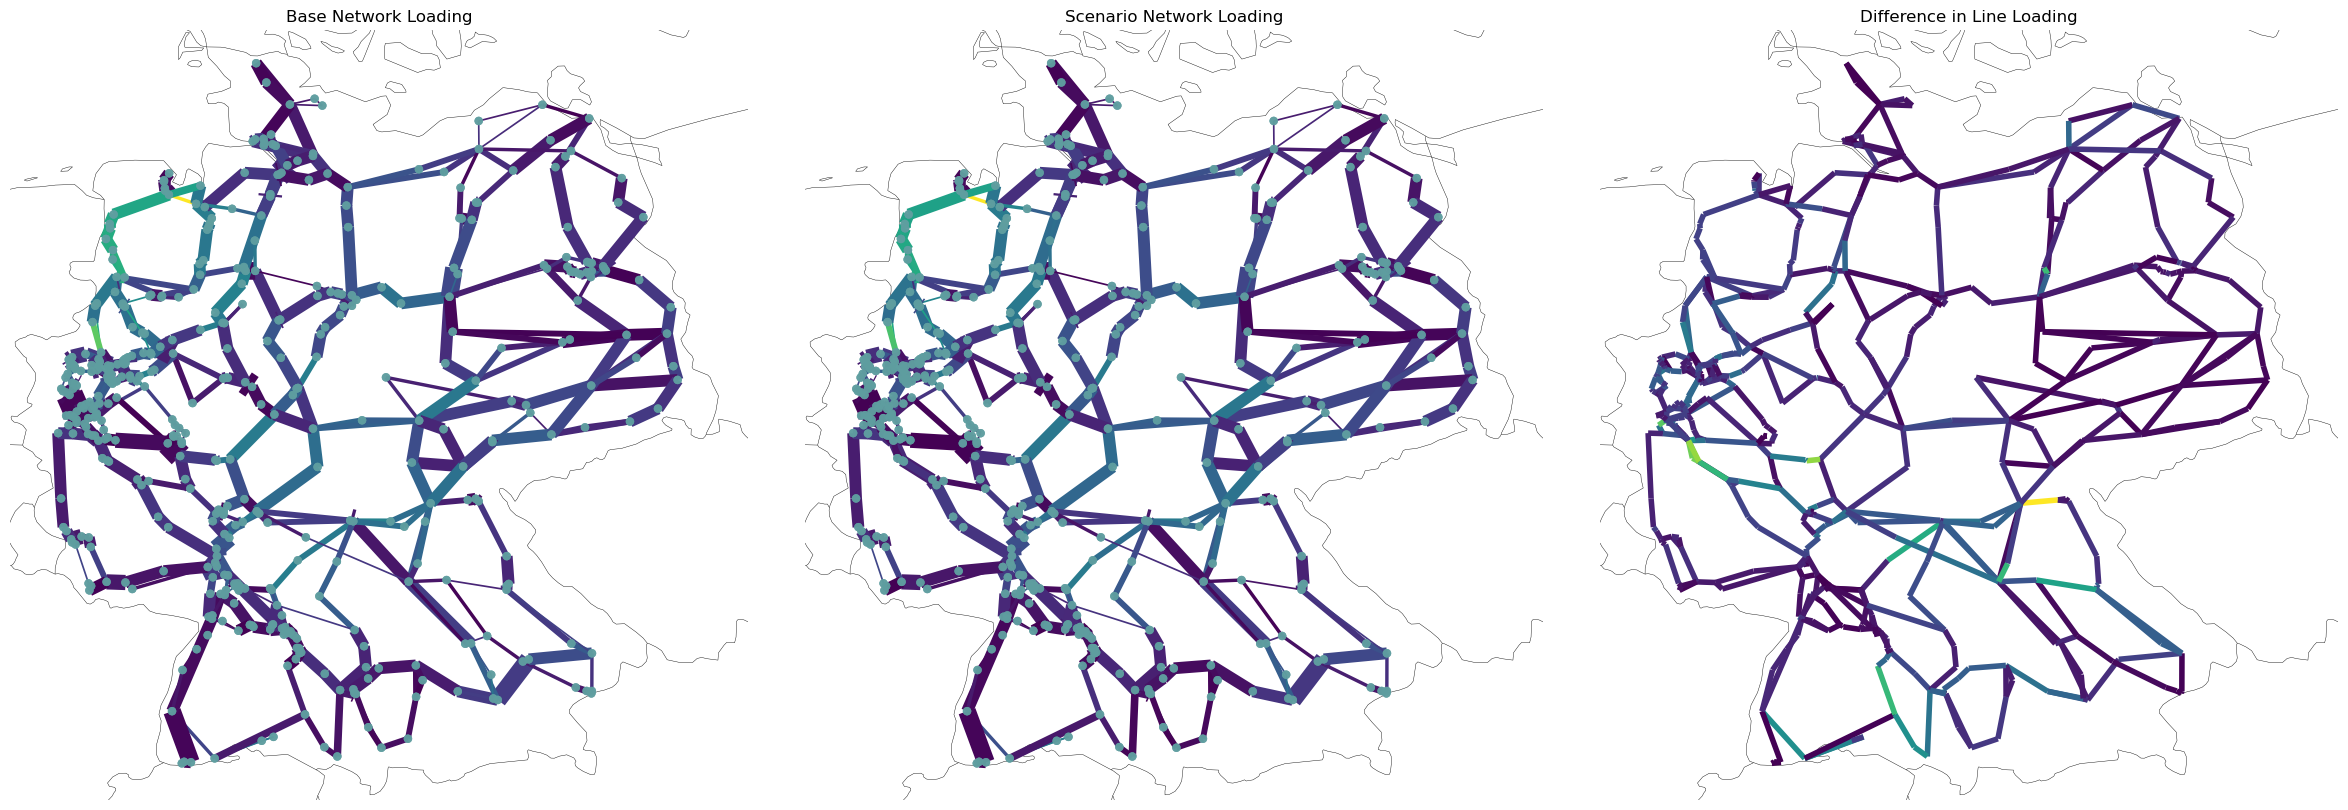

In [23]:
snapshot = n_base.snapshots[12]

bus_size_factor = 1e9
branch_width_factor = 400

fig, axes = plt.subplots(1, 3, figsize=(24, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network ---
def plot_network_loading(n, ax, title):
    # Calculate energy balance for bus sizes
    eb = (
        n.statistics.energy_balance(
            groupby=["bus", "carrier"],
            components=["Generator", "Load", "StorageUnit"],
        )
        .groupby(["bus", "carrier"])
        .sum()
    )
    
    # Calculate line loading for the snapshot
    loading = n.lines_t.p0.loc[snapshot] / n.lines.s_nom
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=eb.abs().sum() / bus_size_factor,
        bus_alpha=0.7,
        line_colors=loading.abs(),
        line_width=n.lines.s_nom / branch_width_factor, # Relate width to capacity
        link_width=n.links.p_nom / branch_width_factor, # Relate width to capacity
    )

# --- Plot Base and Scenario Networks ---
plot_network_loading(n_base, axes[0], "Base Network Loading")
plot_network_loading(n_scenario, axes[1], "Scenario Network Loading")


# --- Plot Difference ---
loading_base = n_base.lines_t.p0.loc[snapshot] / n_base.lines.s_nom
loading_scenario = n_scenario.lines_t.p0.loc[snapshot] / n_scenario.lines.s_nom
loading_diff = (loading_scenario - loading_base).abs()

n_base.plot(
    ax=axes[2], 
    geomap=True, 
    line_width = 4,
    link_width = 4,
    line_colors=loading_diff, 
    title="Difference in Line Loading",
    bus_sizes=0 # Keep buses small for difference plot
)


plt.tight_layout()
plt.show()

### Offshore Wind Curtailment

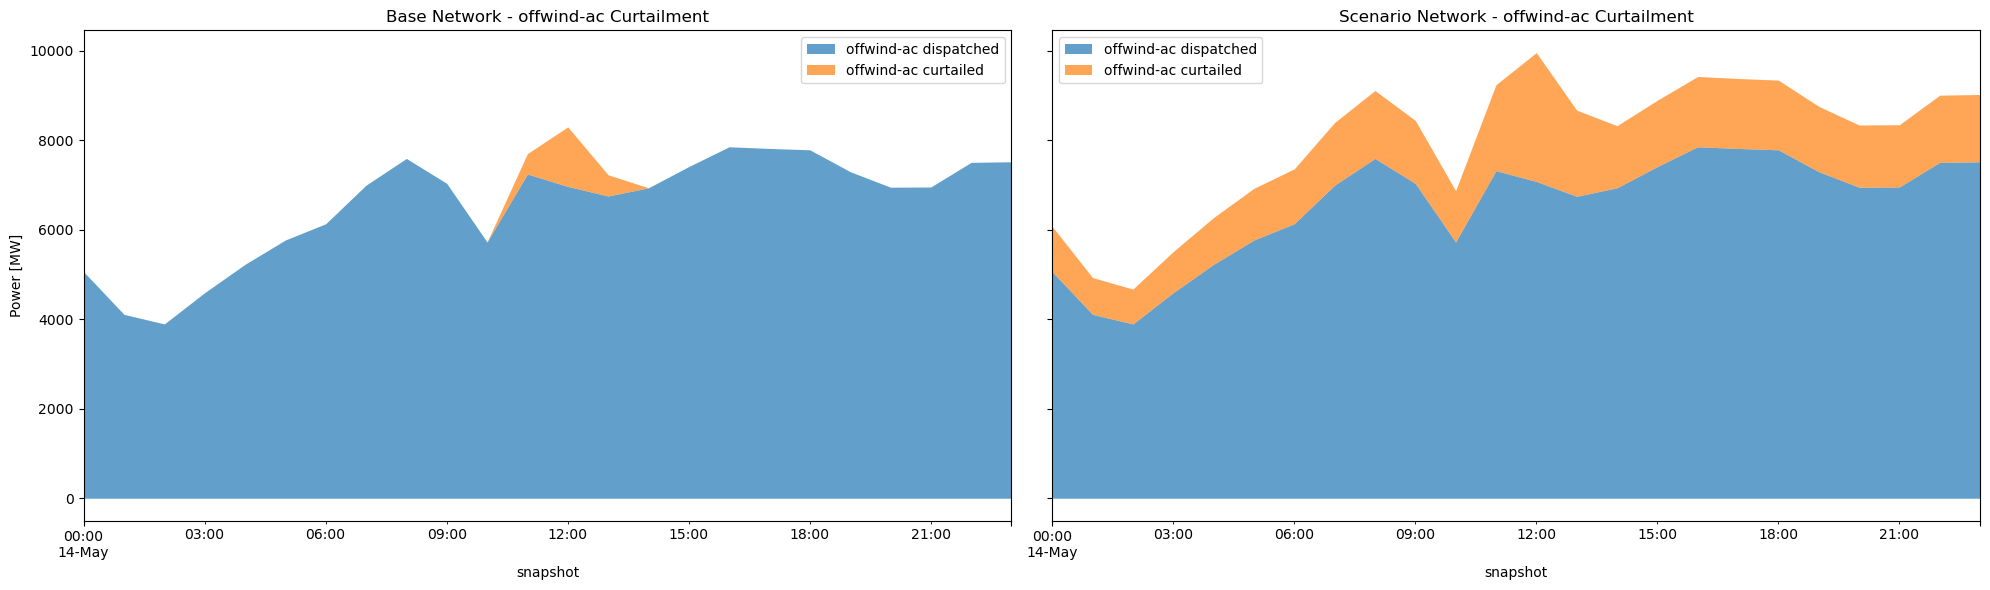

In [12]:
def plot_curtailment(n, carrier, ax):
    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom).T.groupby(n.generators.carrier).sum().T
    p_dispatched = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_curtailed = p_available - p_dispatched
    
    # Correct for any minor negative values from floating point inaccuracies
    p_curtailed[p_curtailed < 0] = 0
    
    df = pd.DataFrame({
        f"{carrier} dispatched": p_dispatched[carrier],
        f"{carrier} curtailed": p_curtailed[carrier]
    })
    
    df.plot(kind="area", ax=ax, lw=0, alpha=0.7)
    ax.set_title(f"{n.name} - {carrier} Curtailment")
    ax.set_ylabel("Power [MW]")

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

plot_curtailment(n_base, "offwind-ac", axes[0])
plot_curtailment(n_scenario, "offwind-ac", axes[1])

plt.tight_layout()
plt.show()

## 4. Generation and Capacity Comparison

### Installed Capacity by Carrier

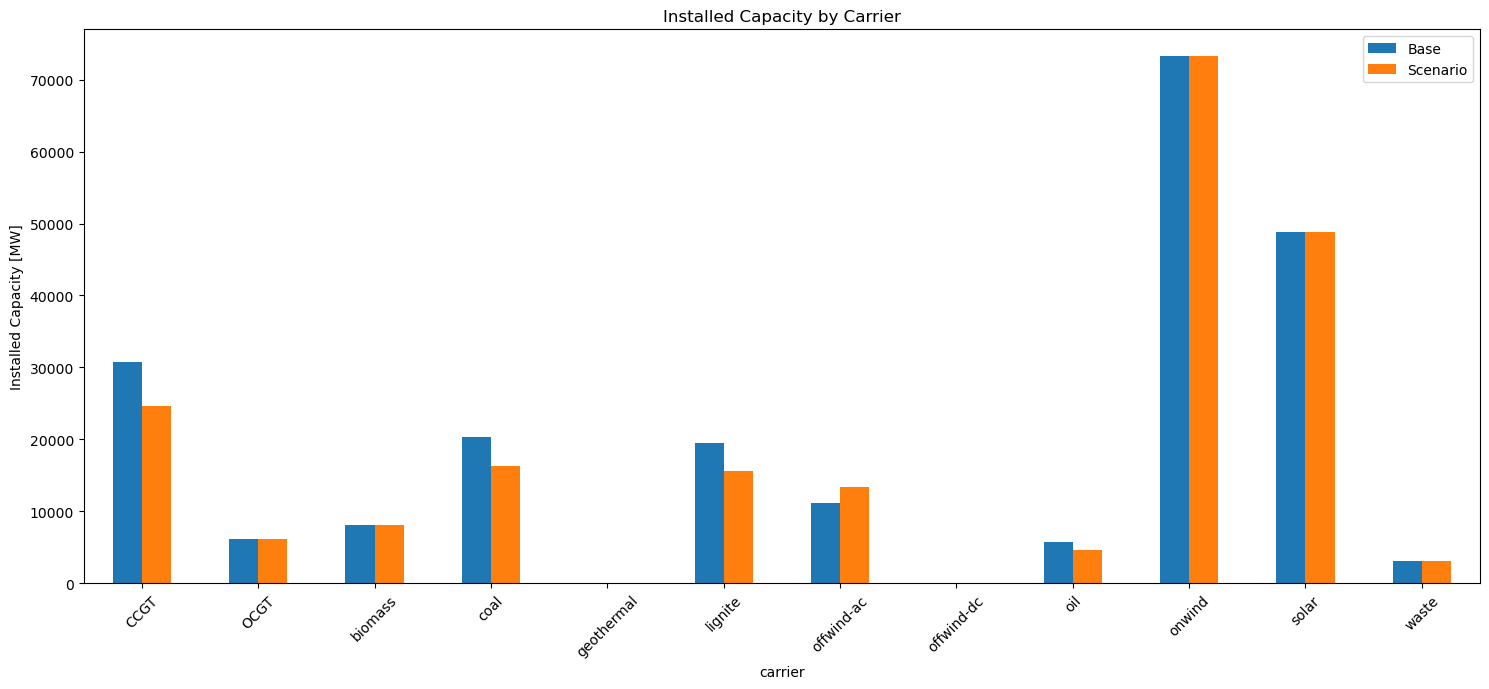

In [13]:
p_nom_base = n_base.generators.groupby("carrier").p_nom.sum()
p_nom_scenario = n_scenario.generators.groupby("carrier").p_nom.sum()

df = pd.DataFrame({
    "Base": p_nom_base,
    "Scenario": p_nom_scenario
}).dropna()

df.plot(kind="bar", figsize=(15, 7), rot=45)
plt.ylabel("Installed Capacity [MW]")
plt.title("Installed Capacity by Carrier")
plt.tight_layout()
plt.show()

### Power Dispatch by Carrier

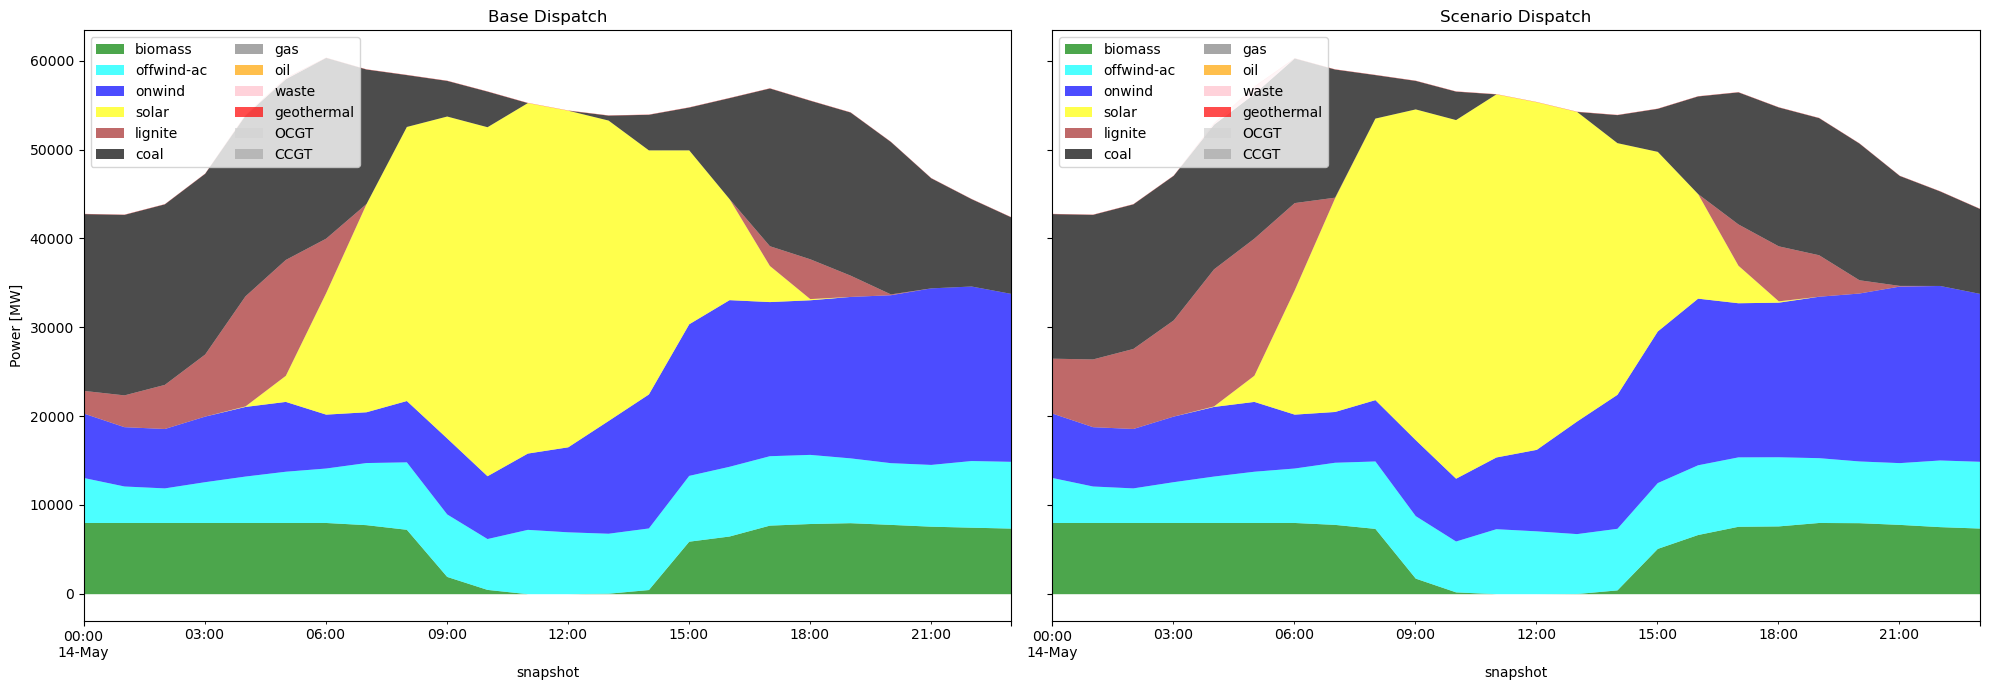

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# --- Define Colors and Order ---
colors = {
    "biomass": "green", "coal": "black", "lignite": "brown",
    "offwind-ac": "cyan", "onwind": "blue", "solar": "yellow",
    "gas": "gray", "oil": "orange", "waste": "pink", "geothermal": "red",
    "OCGT": "lightgray", "CCGT": "darkgray"
}

cols = [
    "biomass", "offwind-ac", "onwind", "solar", "lignite", "coal", "gas", "oil", "waste", "geothermal", "OCGT", "CCGT"
]

# --- Helper function for plotting ---
def plot_dispatch(n, ax, title):
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    
    # Reorder and fill missing columns
    p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)
    
    # Get colors in the correct order
    c = [colors.get(col, "gray") for col in p_by_carrier.columns]
    
    p_by_carrier.plot(kind="area", ax=ax, lw=0, title=title, color=c, alpha=0.7)
    ax.set_ylabel("Power [MW]")
    ax.legend(ncol=2, loc="upper left")

# --- Plotting ---
plot_dispatch(n_base, axes[0], "Base Dispatch")
plot_dispatch(n_scenario, axes[1], "Scenario Dispatch")

plt.tight_layout()
plt.show()

### Total Energy Production by Carrier

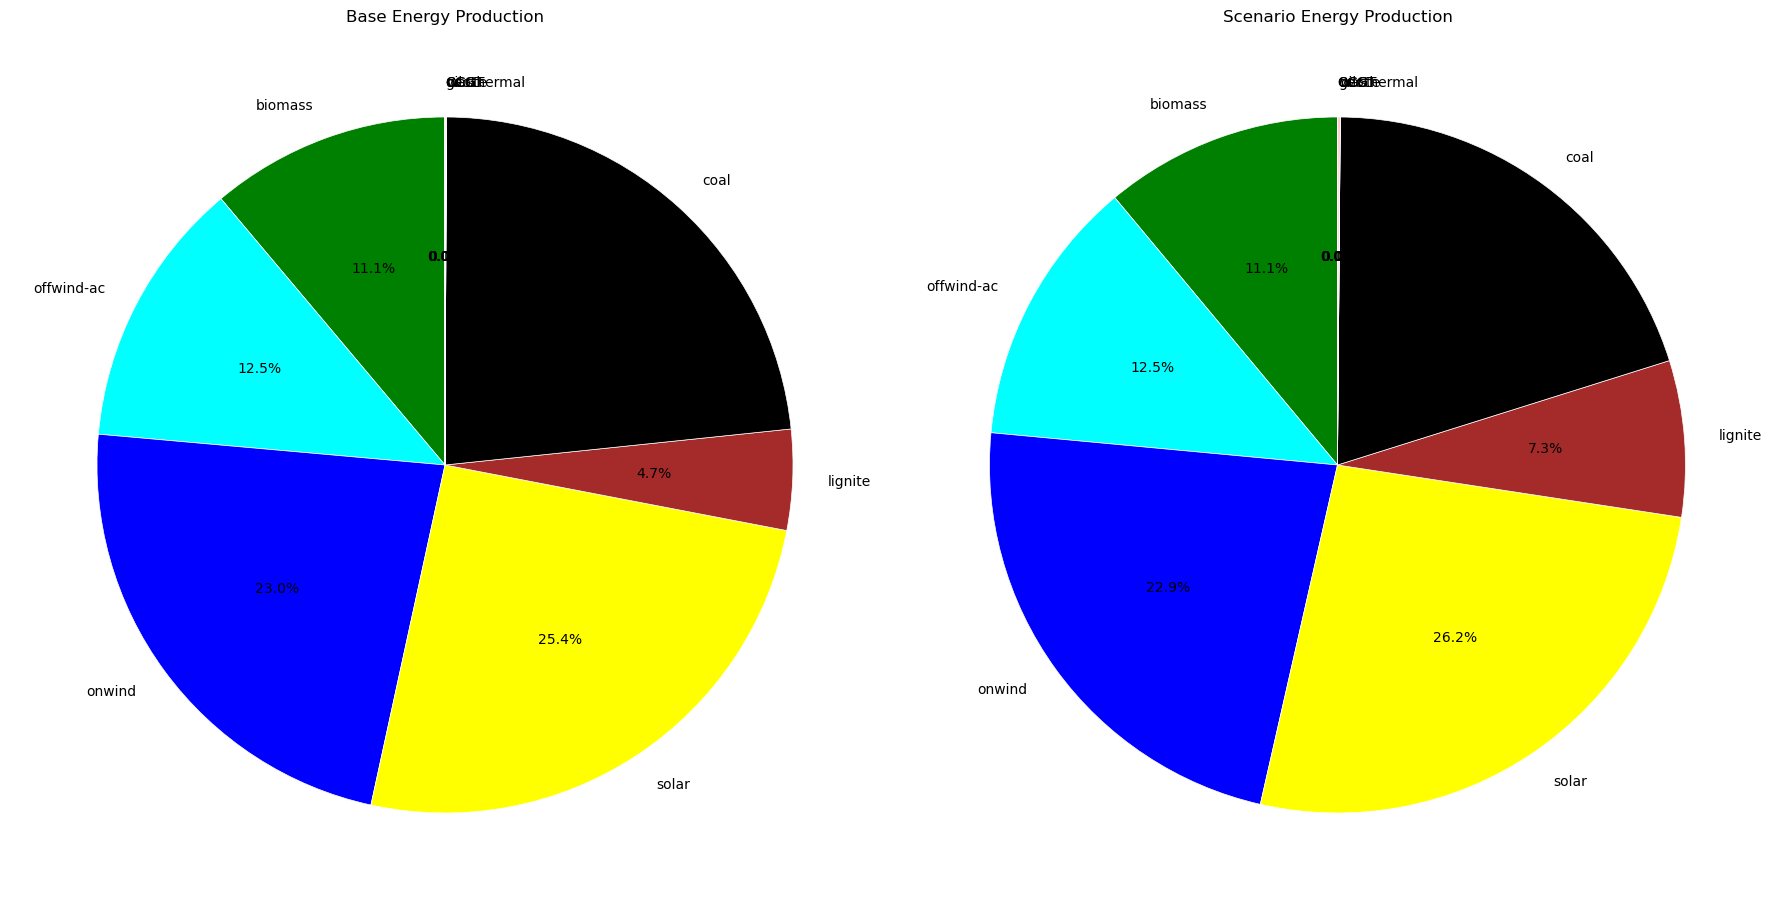

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# --- Define Colors and Order (same as dispatch plot) ---
colors = {
    "biomass": "green", "coal": "black", "lignite": "brown",
    "offwind-ac": "cyan", "onwind": "blue", "solar": "yellow",
    "gas": "gray", "oil": "orange", "waste": "pink", "geothermal": "red",
    "OCGT": "lightgray", "CCGT": "darkgray"
}

# --- Helper function for plotting pie chart ---
def plot_energy_pie(p_by_carrier, ax, title):
    energy_total = p_by_carrier.sum()
    # Filter out carriers with zero or negligible energy
    energy_total = energy_total[energy_total > 0.1]
    
    # Get colors for the carriers that are present
    pie_colors = [colors.get(carrier, "grey") for carrier in energy_total.index]

    energy_total.plot(
        kind="pie", 
        ax=ax, 
        autopct='%1.1f%%', 
        startangle=90, 
        title=title,
        colors=pie_colors,
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'} # Add white borders for clarity
    )
    ax.set_ylabel("")

# --- Plotting ---
# These variables are calculated in the "Power Dispatch" cell above
plot_energy_pie(p_by_carrier_base, axes[0], "Base Energy Production")
plot_energy_pie(p_by_carrier_scenario, axes[1], "Scenario Energy Production")


plt.tight_layout()
plt.show()